# Modelagem — UNESCO World Heritage Sites

Notebook de modelagem construído sobre o dataset processado em `01_eda.ipynb`.

| Fase | Conteúdo |
|---|---|
| **1** | Análise temporal — série histórica por década, categoria e região |
| **2** | Similaridade por NLP — TF-IDF + similaridade cosseno sobre `full_text` |
| **3** | Clustering geográfico — DBSCAN com `metric="haversine"` |

## Importações

In [17]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

NORD_PALETTE = [
    "#88C0D0", "#A3BE8C", "#EBCB8B",
    "#BF616A", "#B48EAD", "#D08770", "#81A1C1",
]

sns.set_theme(style="darkgrid", palette=NORD_PALETTE)
plt.rcParams.update({
    "figure.facecolor": "#2E3440",
    "axes.facecolor": "#3B4252",
    "text.color": "#ECEFF4",
    "axes.labelcolor": "#ECEFF4",
    "xtick.color": "#D8DEE9",
    "ytick.color": "#D8DEE9",
    "axes.edgecolor": "#4C566A",
    "grid.color": "#434C5E",
    "axes.titlecolor": "#ECEFF4",
    "legend.facecolor": "#3B4252",
    "legend.edgecolor": "#4C566A",
})

## Carregamento dos Dados

In [18]:
PROCESSED_PATH = Path("..") / "data" / "processed" / "whc_processed.csv"

df = pd.read_csv(PROCESSED_PATH, sep=";", encoding="utf-8")
print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df[["name_en", "year_inscribed", "decade_inscribed", "category", "region"]].head()

Shape: 1,248 linhas × 46 colunas


,name_en,year_inscribed,decade_inscribed,category,region
0,Natural and Cultural Heritage of the Ohrid region,1979,1970,Mixed,Europe and North America
1,Tipasa,1982,1980,Cultural,Arab States
2,Antigua Naval Dockyard and Related Archaeologi...,2016,2010,Cultural,Latin America and the Caribbean
3,Jesuit Block and Estancias of Córdoba,2000,2000,Cultural,Latin America and the Caribbean
4,Cathedral and Churches of Echmiatsin and the A...,2000,2000,Cultural,Europe and North America


# 1. Análise Temporal

Evolução das inscrições ao longo do tempo, analisada em três eixos.

## 1.1 Série histórica de inscrições por década

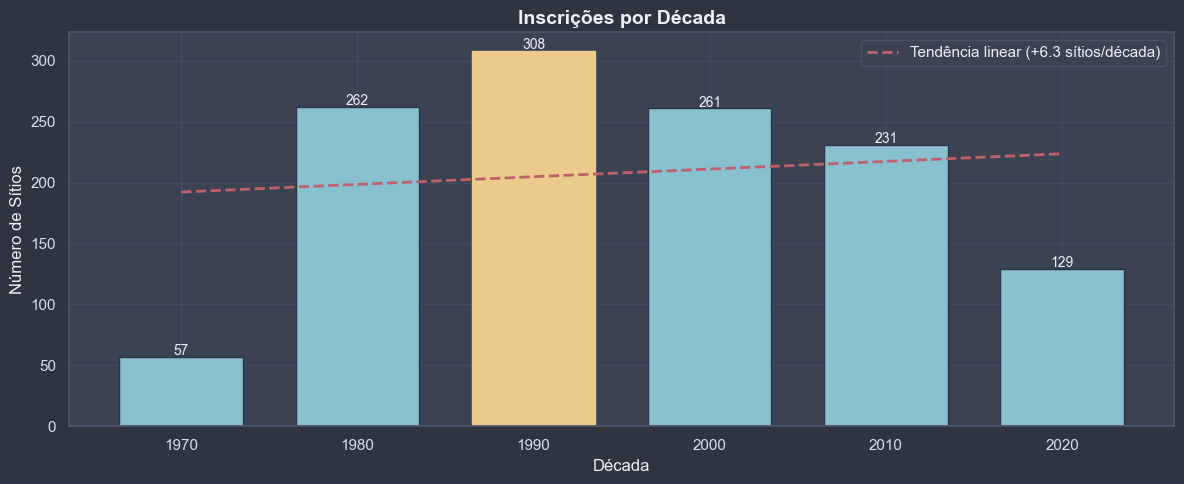

Pico: década de 1990s — 308 inscrições
Total acumulado: 1,248 sítios


In [19]:
temporal = (
    df.dropna(subset=["decade_inscribed"])
    .assign(decade=lambda x: x["decade_inscribed"].astype(float).astype(int))
    .groupby("decade")
    .size()
    .rename("count")
    .reset_index()
)

x = np.arange(len(temporal))
coeffs = np.polyfit(x, temporal["count"].values, 1)
trend_y = np.poly1d(coeffs)(x)
peak_idx = int(temporal["count"].idxmax())

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(x, temporal["count"], color="#88C0D0", edgecolor="#2E3440", width=0.7)
bars[peak_idx].set_color("#EBCB8B")

for bar, val in zip(bars, temporal["count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        str(int(val)),
        ha="center", color="#ECEFF4", fontsize=10,
    )

ax.plot(
    x, trend_y,
    color="#BF616A", linewidth=2, linestyle="--",
    label=f"Tendência linear ({'+' if coeffs[0] >= 0 else ''}{coeffs[0]:.1f} sítios/década)",
)

ax.set_xticks(x)
ax.set_xticklabels(temporal["decade"].astype(str))
ax.set_title("Inscrições por Década", fontsize=14, fontweight="bold")
ax.set_xlabel("Década")
ax.set_ylabel("Número de Sítios")
ax.legend()
plt.tight_layout()
plt.show()

peak_decade = temporal.loc[peak_idx, "decade"]
print(f"Pico: década de {peak_decade}s — {temporal.loc[peak_idx, 'count']} inscrições")
print(f"Total acumulado: {temporal['count'].sum():,} sítios")

## 1.2 Composição por categoria ao longo das décadas

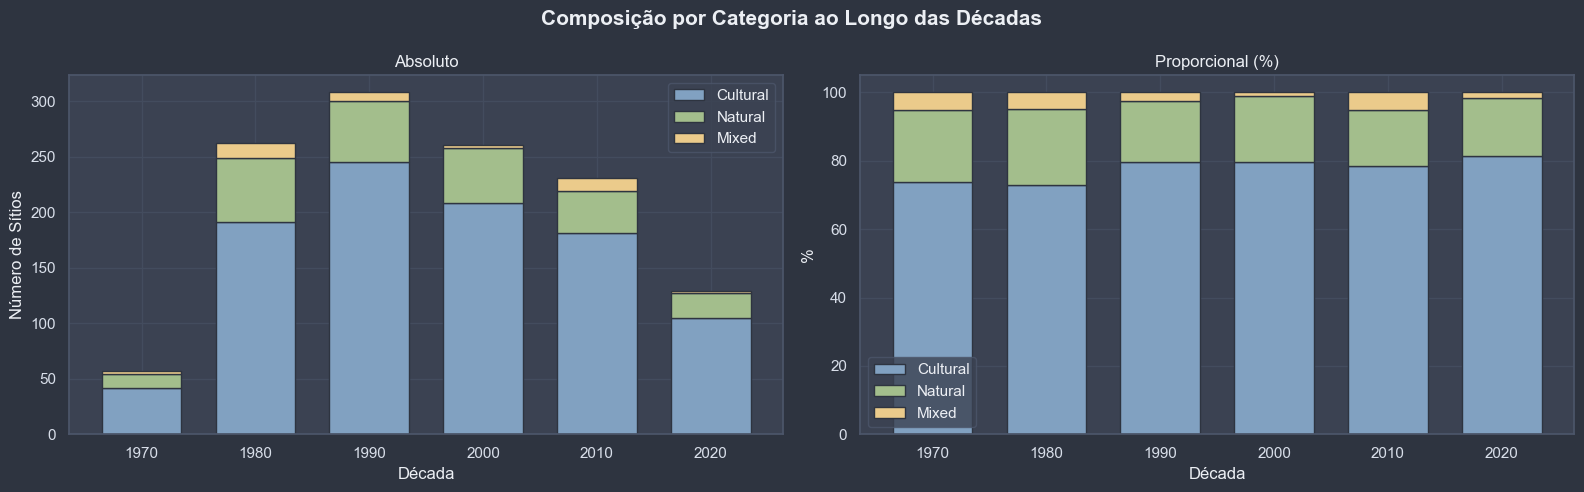

Proporção média por categoria:
category
Cultural    77.6
Mixed        3.5
Natural     19.0


In [20]:
cat_decade = (
    df.dropna(subset=["decade_inscribed"])
    .assign(decade=lambda x: x["decade_inscribed"].astype(float).astype(int))
    .groupby(["decade", "category"])
    .size()
    .unstack(fill_value=0)
)
cat_decade_pct = cat_decade.div(cat_decade.sum(axis=1), axis=0) * 100

cat_colors = {"Cultural": "#81A1C1", "Natural": "#A3BE8C", "Mixed": "#EBCB8B"}
categories = [c for c in ["Cultural", "Natural", "Mixed"] if c in cat_decade.columns]
x = np.arange(len(cat_decade))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title, ylabel in [
    (ax1, cat_decade, "Absoluto", "Número de Sítios"),
    (ax2, cat_decade_pct, "Proporcional (%)", "%"),
]:
    bottom = np.zeros(len(data))
    for cat in categories:
        vals = data[cat].values
        ax.bar(x, vals, bottom=bottom, label=cat, color=cat_colors[cat], edgecolor="#2E3440", width=0.7)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(cat_decade.index.astype(str))
    ax.set_title(title)
    ax.set_xlabel("Década")
    ax.set_ylabel(ylabel)
    ax.legend()

fig.suptitle("Composição por Categoria ao Longo das Décadas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print("Proporção média por categoria:")
print(cat_decade_pct.mean().round(1).rename("%").to_string())

## 1.3 Distribuição por região e década

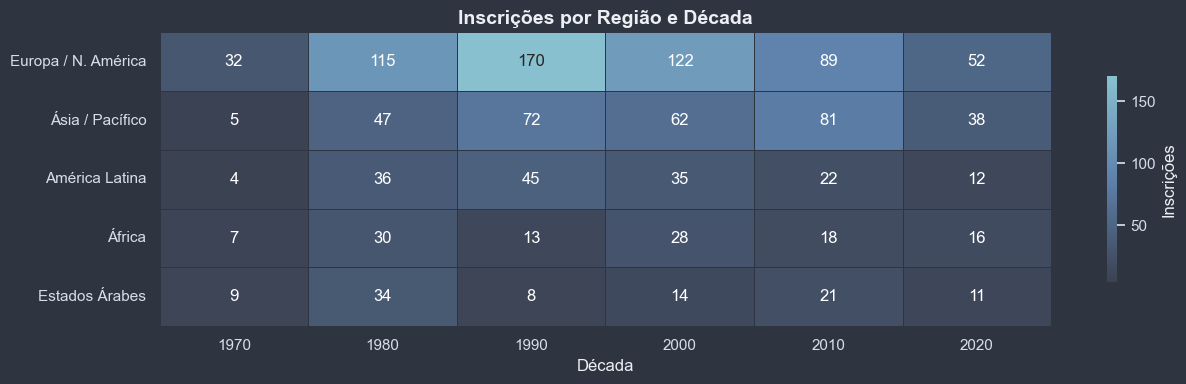

Total por região:
region
Europa / N. América    580
Ásia / Pacífico        305
América Latina         154
África                 112
Estados Árabes          97


In [21]:
REGION_SHORT: dict[str, str] = {
    "Europe and North America": "Europa / N. América",
    "Asia and the Pacific": "Ásia / Pacífico",
    "Latin America and the Caribbean": "América Latina",
    "Africa": "África",
    "Arab States": "Estados Árabes",
}

region_decade = (
    df.dropna(subset=["decade_inscribed"])
    .assign(decade=lambda x: x["decade_inscribed"].astype(float).astype(int))
    .groupby(["region", "decade"])
    .size()
    .unstack(fill_value=0)
)
region_decade.index = region_decade.index.map(lambda r: REGION_SHORT.get(r, r))
region_decade = region_decade.loc[region_decade.sum(axis=1).sort_values(ascending=False).index]

nord_seq = LinearSegmentedColormap.from_list("nord_seq", ["#3B4252", "#5E81AC", "#88C0D0"])

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    region_decade,
    annot=True,
    fmt="d",
    cmap=nord_seq,
    linewidths=0.5,
    linecolor="#2E3440",
    ax=ax,
    cbar_kws={"shrink": 0.7, "label": "Inscrições"},
)
ax.set_title("Inscrições por Região e Década", fontsize=14, fontweight="bold")
ax.set_xlabel("Década")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Total por região:")
print(region_decade.sum(axis=1).rename("total").to_string())

# 2. Similaridade por NLP

Representação vetorial dos sítios a partir de `full_text` (nome + descrição em inglês) via **TF-IDF**,
seguida de **similaridade cosseno** para identificar sítios com vocabulário descritivo similar.

## 2.1 Vetorização TF-IDF

`TfidfVectorizer` com unigramas e bigramas (`ngram_range=(1, 2)`), `sublinear_tf=True`
para reduzir o peso de termos muito frequentes e `stop_words="english"`.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

nlp_df = df.dropna(subset=["full_text"]).reset_index(drop=True)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=8_000,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=2,
)
tfidf_matrix = vectorizer.fit_transform(nlp_df["full_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

n_docs, n_terms = tfidf_matrix.shape
sparsity = (1 - tfidf_matrix.nnz / (n_docs * n_terms)) * 100

print(f"Documentos  : {n_docs:,}")
print(f"Vocabulário : {n_terms:,} termos")
print(f"Esparsidade : {sparsity:.1f}%")

Documentos  : 1,248
Vocabulário : 8,000 termos
Esparsidade : 99.3%


## 2.2 Termos mais relevantes por categoria

Soma dos scores TF-IDF de todos os documentos de cada categoria — revela o vocabulário
característico de sítios Culturais, Naturais e Mistos.

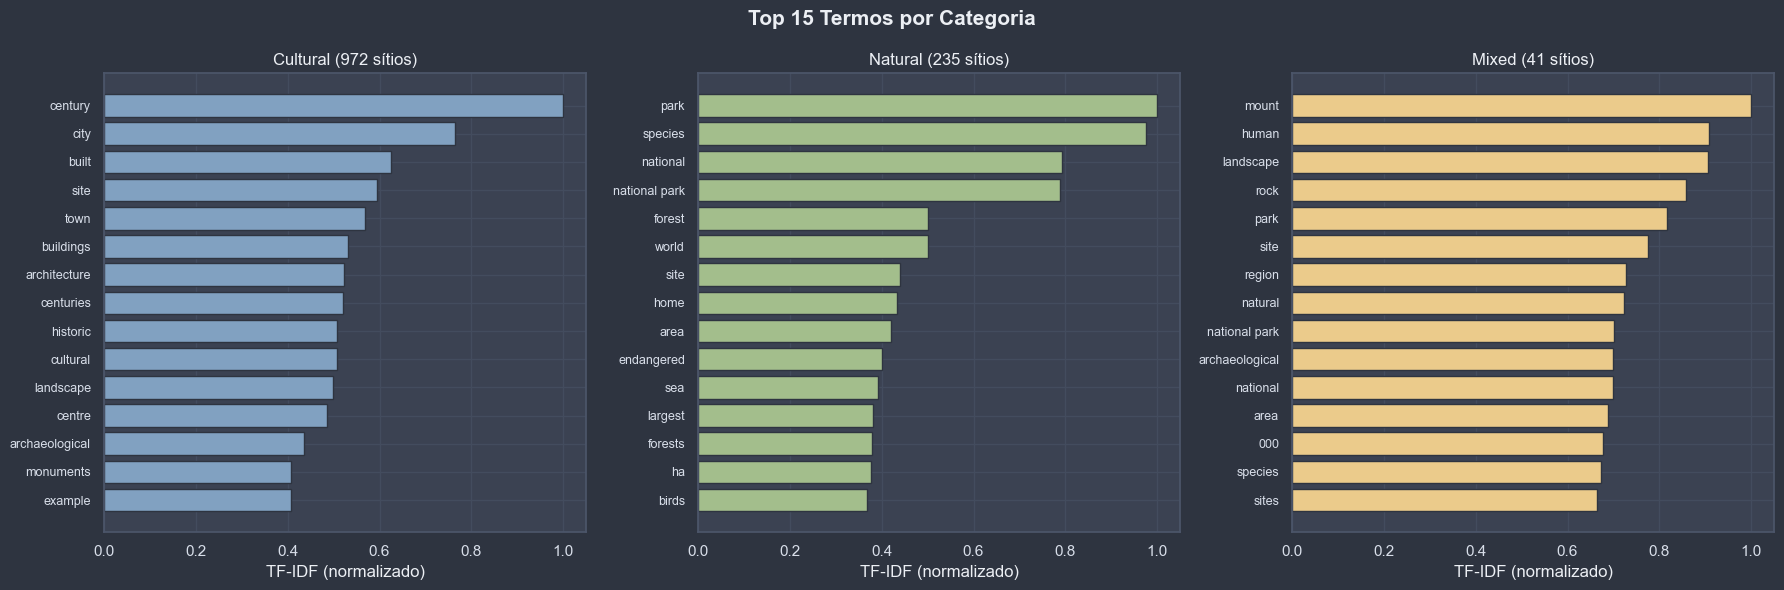

In [23]:
top_n_terms = 15
cat_colors_map: dict[str, str] = {
    "Cultural": "#81A1C1",
    "Natural": "#A3BE8C",
    "Mixed": "#EBCB8B",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cat in zip(axes, ["Cultural", "Natural", "Mixed"]):
    mask = (nlp_df["category"] == cat).to_numpy()
    cat_tfidf_sum = np.asarray(tfidf_matrix[mask].sum(axis=0)).flatten()
    top_idx = cat_tfidf_sum.argsort()[::-1][:top_n_terms]
    top_terms = feature_names[top_idx]
    top_scores = cat_tfidf_sum[top_idx] / cat_tfidf_sum[top_idx].max()

    ax.barh(
        range(top_n_terms, 0, -1),
        top_scores,
        color=cat_colors_map.get(cat, "#88C0D0"),
        edgecolor="#2E3440",
    )
    ax.set_yticks(range(top_n_terms, 0, -1))
    ax.set_yticklabels(top_terms, fontsize=9)
    ax.set_title(f"{cat} ({mask.sum()} sítios)")
    ax.set_xlabel("TF-IDF (normalizado)")

fig.suptitle("Top 15 Termos por Categoria", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.3 Consulta de similaridade

`linear_kernel` computa a similaridade cosseno entre o vetor do sítio consultado e todos os
demais (equivalente a `cosine_similarity` para vetores L2-normalizados, porém mais eficiente
para matrizes esparsas).

In [24]:
from sklearn.metrics.pairwise import linear_kernel


def find_similar_sites(site_name: str, top_n: int = 8) -> pd.DataFrame:
    """Returns the top_n UNESCO sites most similar to site_name by TF-IDF cosine similarity."""
    matches = nlp_df[nlp_df["name_en"].str.contains(site_name, case=False, na=False)]
    if matches.empty:
        raise ValueError(f"Nenhum sítio encontrado com '{site_name}'")
    idx = int(matches.index[0])
    scores = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
    scores[idx] = -1.0
    top_idx = scores.argsort()[::-1][:top_n]
    return (
        nlp_df.loc[top_idx, ["name_en", "category", "region"]]
        .assign(similarity=scores[top_idx].round(4))
        .reset_index(drop=True)
    )


for query in ["Stonehenge", "Yellowstone", "Angkor"]:
    matches = nlp_df[nlp_df["name_en"].str.contains(query, case=False, na=False)]
    if matches.empty:
        print(f"'{query}' não encontrado\n")
        continue
    query_name = matches.iloc[0]["name_en"]
    print(f"\n── Top 8 similares a: «{query_name}» ──")
    print(find_similar_sites(query).to_string(index=False))
    print()


── Top 8 similares a: «Stonehenge, Avebury and Associated Sites» ──
                                                                                                              name_en category                   region  similarity
                                                                  Bahá’i Holy Places in Haifa and the Western Galilee Cultural Europe and North America      0.2209
                                                                    Megaliths of Carnac and of the shores of Morbihan Cultural Europe and North America      0.1280
                                                                                            Heart of Neolithic Orkney Cultural Europe and North America      0.1271
                                                                                          Stone Circles of Senegambia Cultural                   Africa      0.1254
                                                                           Prehistoric Pile Dwellings around th

## 2.4 Similaridade textual média entre regiões

Vetor TF-IDF médio de cada região (média das linhas da matriz), seguido de similaridade
cosseno entre pares — mostra quais regiões compartilham vocabulário descritivo similar.

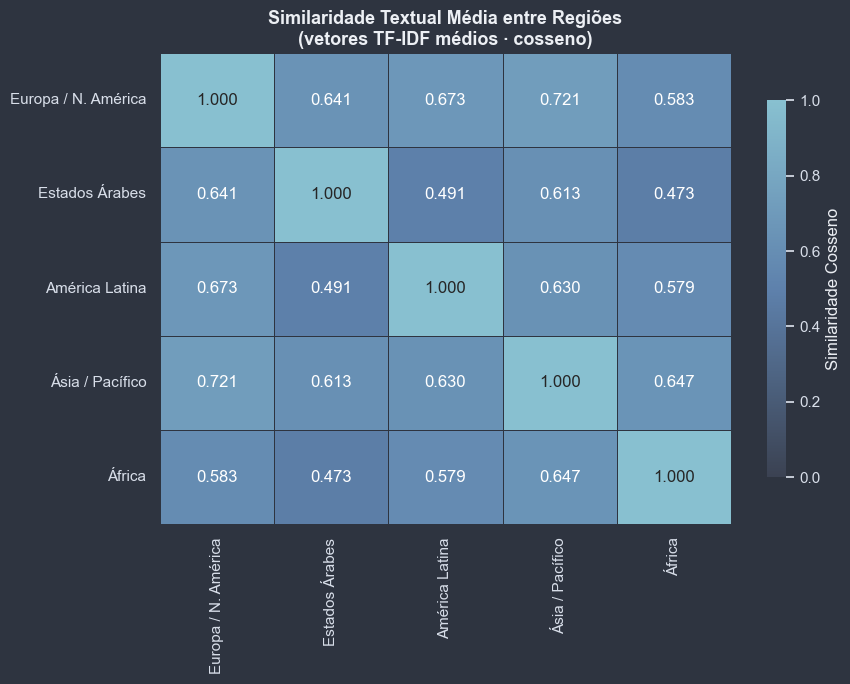

Top 3 pares de regiões mais similares:
           região_1        região_2  similarity
Europa / N. América Ásia / Pacífico    0.721083
Europa / N. América  América Latina    0.672719
    Ásia / Pacífico          África    0.646744


In [25]:
from sklearn.metrics.pairwise import cosine_similarity

region_vecs: dict[str, np.ndarray] = {
    region: np.asarray(
        tfidf_matrix[(nlp_df["region"] == region).to_numpy()].mean(axis=0)
    ).flatten()
    for region in nlp_df["region"].dropna().unique()
}

region_names = list(region_vecs.keys())
region_matrix = np.vstack([region_vecs[r] for r in region_names])
region_sim = cosine_similarity(region_matrix)

region_sim_df = pd.DataFrame(region_sim, index=region_names, columns=region_names)
region_sim_df.index = region_sim_df.index.map(lambda r: REGION_SHORT.get(r, r))
region_sim_df.columns = region_sim_df.columns.map(lambda r: REGION_SHORT.get(r, r))

nord_seq = LinearSegmentedColormap.from_list("nord_seq", ["#3B4252", "#5E81AC", "#88C0D0"])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    region_sim_df,
    annot=True,
    fmt=".3f",
    cmap=nord_seq,
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    linecolor="#2E3440",
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Similaridade Cosseno"},
)
ax.set_title(
    "Similaridade Textual Média entre Regiões\n(vetores TF-IDF médios · cosseno)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

upper_tri = np.triu(np.ones(region_sim_df.shape, dtype=bool), k=1)
top_pairs = (
    region_sim_df.where(upper_tri)
    .stack()
    .sort_values(ascending=False)
    .head(3)
    .rename("similarity")
    .reset_index()
    .rename(columns={"level_0": "região_1", "level_1": "região_2"})
)
print("Top 3 pares de regiões mais similares:")
print(top_pairs.to_string(index=False))

# 3. Clustering Geográfico (DBSCAN)

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) identifica grupos
de alta densidade sem exigir o número de clusters como parâmetro. Pontos isolados (sítios
geograficamente dispersos) recebem rótulo `-1` (ruído).

| Variante | Features | Métrica |
|---|---|---|
| **Geográfica** | `latitude`, `longitude` | Haversine (respeita curvatura do globo) |
| **Multivariada** | lat/lon + `year_inscribed` + `n_criteria` + `category` | Euclidiana (dados normalizados) |
| **Temática (NLP)** | TF-IDF sobre `full_text` | Cosseno (distância pré-computada) |

## 3.1 Gráfico k-Distâncias — Seleção de eps

Para cada ponto, calcula-se a distância ao k-ésimo vizinho mais próximo (k = `min_samples`).
Ordenando em ordem decrescente, o "cotovelo" da curva indica um `eps` natural para os dados —
abaixo do cotovelo os pontos estão densos; acima, são candidatos a outliers.

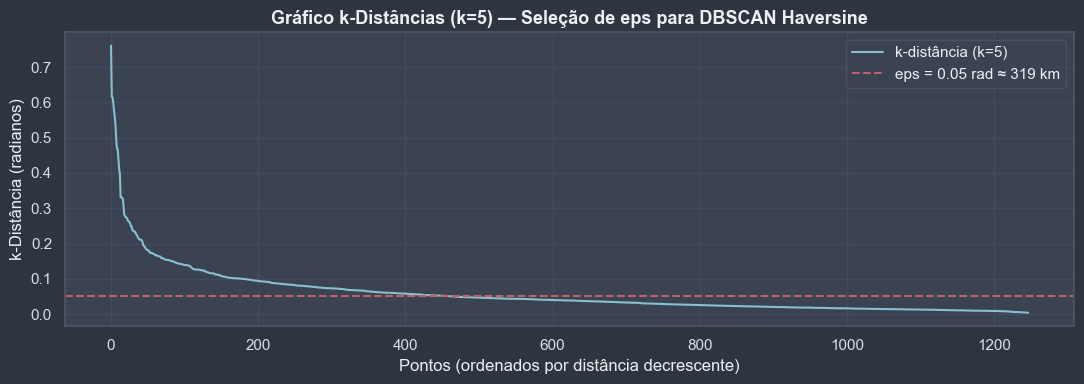

Percentil 90 das k-distâncias: 0.1240 rad
eps escolhido                 : 0.05 rad ≈ 319 km


In [26]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

geo_df = df.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
coords_rad = np.radians(geo_df[["latitude", "longitude"]].values)

K_MIN_SAMPLES = 5
EPS_GEO = 0.05  # radianos; 0.05 rad × 6 371 km ≈ 318 km

nn = NearestNeighbors(n_neighbors=K_MIN_SAMPLES, metric="haversine", algorithm="ball_tree")
nn.fit(coords_rad)
k_distances = np.sort(nn.kneighbors(coords_rad)[0][:, -1])[::-1]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(k_distances, color="#88C0D0", linewidth=1.5, label=f"k-distância (k={K_MIN_SAMPLES})")
ax.axhline(
    y=EPS_GEO, color="#BF616A", linestyle="--", linewidth=1.5,
    label=f"eps = {EPS_GEO} rad ≈ {EPS_GEO * 6_371:.0f} km",
)
ax.set_title(
    f"Gráfico k-Distâncias (k={K_MIN_SAMPLES}) — Seleção de eps para DBSCAN Haversine",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Pontos (ordenados por distância decrescente)")
ax.set_ylabel("k-Distância (radianos)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Percentil 90 das k-distâncias: {np.percentile(k_distances, 90):.4f} rad")
print(f"eps escolhido                 : {EPS_GEO} rad ≈ {EPS_GEO * 6_371:.0f} km")

## 3.2 Variante 1 — Geográfico Puro (haversine)

DBSCAN com `metric="haversine"` e `algorithm="ball_tree"`. As coordenadas são
convertidas para **radianos** (exigência do scikit-learn para essa métrica). O `eps`
selecionado pelo gráfico k-distâncias é aplicado aqui.

In [27]:
dbscan_geo = DBSCAN(eps=EPS_GEO, min_samples=K_MIN_SAMPLES, metric="haversine", algorithm="ball_tree")
geo_df["cluster_geo"] = dbscan_geo.fit_predict(coords_rad)

n_clusters_geo = int(geo_df["cluster_geo"].nunique()) - (1 if -1 in geo_df["cluster_geo"].values else 0)
n_noise_geo = int((geo_df["cluster_geo"] == -1).sum())
print(f"eps              : {EPS_GEO} rad ≈ {EPS_GEO * 6_371:.0f} km  |  min_samples: {K_MIN_SAMPLES}")
print(f"Clusters formados: {n_clusters_geo}")
print(f"Ruído (outliers) : {n_noise_geo} sítios ({n_noise_geo / len(geo_df) * 100:.1f}%)")
print()
print(
    geo_df.groupby("cluster_geo")
    .size()
    .rename("sítios")
    .sort_values(ascending=False)
    .head(10)
    .to_string()
)

eps              : 0.05 rad ≈ 319 km  |  min_samples: 5
Clusters formados: 30
Ruído (outliers) : 366 sítios (29.4%)

cluster_geo
 0     521
-1     366
 1      44
 13     42
 8      26
 18     24
 10     20
 16     20
 5      14
 4      13


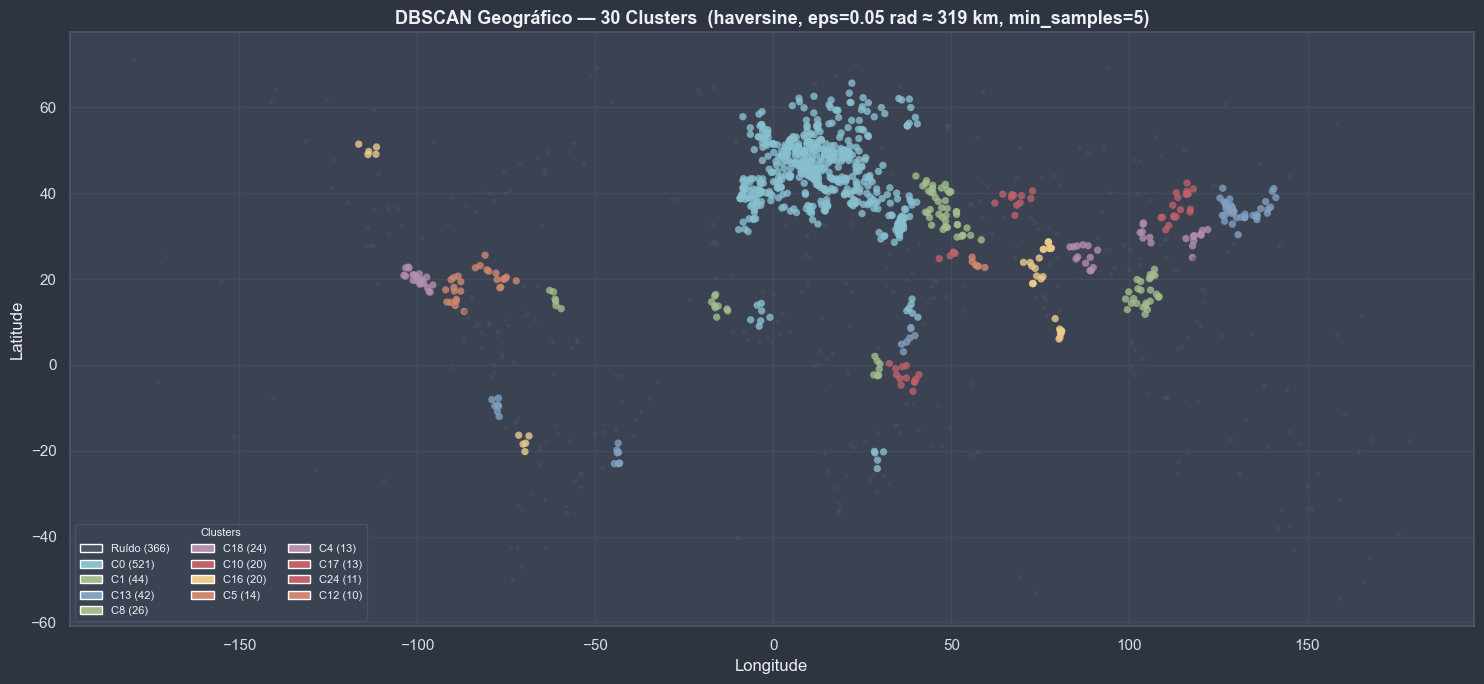

Top 5 maiores clusters — região predominante:
  Cluster  0: 521 sítios — Europe and North America
  Cluster  1:  44 sítios — Asia and the Pacific
  Cluster 13:  42 sítios — Asia and the Pacific
  Cluster  8:  26 sítios — Asia and the Pacific
  Cluster 18:  24 sítios — Latin America and the Caribbean


In [28]:
from matplotlib.patches import Patch

cluster_labels_geo = sorted(geo_df["cluster_geo"].unique())
noise_mask_geo = geo_df["cluster_geo"] == -1
non_noise_geo = [c for c in cluster_labels_geo if c != -1]

palette_geo = NORD_PALETTE * (len(non_noise_geo) // len(NORD_PALETTE) + 1)
color_map_geo = {c: palette_geo[i] for i, c in enumerate(non_noise_geo)}
color_map_geo[-1] = "#4C566A"
colors_geo = geo_df["cluster_geo"].map(color_map_geo)

fig, ax = plt.subplots(figsize=(15, 7))
ax.scatter(
    geo_df["longitude"], geo_df["latitude"],
    c=colors_geo,
    s=np.where(noise_mask_geo, 12, 28),
    alpha=np.where(noise_mask_geo, 0.35, 0.80),
    edgecolors="none",
)

top_by_size = sorted(non_noise_geo, key=lambda c: -(geo_df["cluster_geo"] == c).sum())[:12]
handles = [Patch(facecolor="#4C566A", label=f"Ruído ({int(noise_mask_geo.sum())})")]
for c in top_by_size:
    n = int((geo_df["cluster_geo"] == c).sum())
    handles.append(Patch(facecolor=color_map_geo[c], label=f"C{c} ({n})"))

ax.legend(handles=handles, loc="lower left", fontsize=8, ncol=3, title="Clusters", title_fontsize=8)
ax.set_title(
    f"DBSCAN Geográfico — {n_clusters_geo} Clusters  "
    f"(haversine, eps={EPS_GEO} rad ≈ {EPS_GEO * 6_371:.0f} km, min_samples={K_MIN_SAMPLES})",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print("Top 5 maiores clusters — região predominante:")
for c in top_by_size[:5]:
    mask = geo_df["cluster_geo"] == c
    top_region = geo_df.loc[mask, "region"].value_counts().index[0]
    print(f"  Cluster {c:2d}: {int(mask.sum()):3d} sítios — {top_region}")

# 4. Classificação Temática

12 categorias criadas para oferecer uma taxonomia mais evocativa que a classificação
oficial UNESCO (Cultural / Natural / Mixed). A classificação usa **prototype matching**:
cada categoria é representada por um texto descritivo em inglês; sítios são atribuídos
à categoria cujo protótipo TF-IDF mais se assemelha à sua descrição.

| Categoria | Exemplos esperados |
|---|---|
| Ruínas e sítios arqueológicos | Machu Picchu, Palmira, Persépolis |
| Centros urbanos vivos | Veneza, Cracóvia, Salvador |
| Conjuntos religiosos e sagrados | Santiago de Compostela, Angkor Wat |
| Fortificações e sistemas defensivos | Grande Muralha, Carcassonne, Ávila |
| Paisagens culturais e parques humanizados | Lavaux, Ifugao, vinhedos do Porto |
| Palácios e sedes de poder político | Versalhes, Cidade Proibida, Westminster |
| Necrópoles e espaços funerários | Vale dos Reis, Pirâmides, Père-Lachaise |
| Engenharia e infraestrutura histórica | Pont du Gard, Canal do Panamá |
| Conjuntos rurais e aldeias | Alberobello, Ouro Preto |
| Sítios industriais e tecnológicos | Fagus, Wieliczka, Ferrovia do Rétia |
| Arte rupestre e inscrições primitivas | Lascaux, Serra da Capivara, Altamira |
| Monumentos comemorativos e memoriais | Estátua da Liberdade, Hiroshima |

## 4.1 Protótipos e Similaridade Cosseno

Cada categoria é representada por um **texto-protótipo** em inglês com o vocabulário
característico daquele tipo de sítio. Os protótipos são transformados pelo
`TfidfVectorizer` já ajustado na Fase 2 (mesmo espaço vetorial de 8000 termos) e a
similaridade cosseno entre cada sítio e cada protótipo produz uma matriz **1248 × 12**.

- **Categoria primária**: `argmax` da linha (maior score de similaridade).
- **Multi-label**: todas as categorias com score acima de um limiar (padrão: 0,05).

In [29]:
from sklearn.metrics.pairwise import cosine_similarity as pairwise_cosine

CATEGORY_PROTOTYPES: dict[str, str] = {
    "Ruínas e sítios arqueológicos": (
        "Ancient ruined city, temple ruins or abandoned archaeological settlement. "
        "Excavated remains of walls, columns, inscriptions and artifacts uncovering "
        "a prehistoric or historic civilization. Monumental structures in ruin, "
        "ceremonial complexes and unearthed dwellings of ancient inhabitants."
    ),
    "Centros urbanos vivos": (
        "Historic centre or old town of a city still inhabited today. The preserved "
        "historic district features traditional architecture, historic streets and an "
        "urban fabric of residential and commercial buildings. Historic town with "
        "continuous occupation and a living urban community."
    ),
    "Conjuntos religiosos e sagrados": (
        "Church, monastery, cathedral, mosque, temple or shrine of outstanding "
        "religious significance. Sacred site for pilgrimage, worship and spiritual "
        "devotion. Buddhist, Hindu, Islamic or Christian religious architecture and "
        "monastic community of monks, nuns or clergy."
    ),
    "Fortificações e sistemas defensivos": (
        "Fortress, castle, fortified city walls, ramparts, citadel or military "
        "bastion. Medieval or historic defensive system with towers, battlements "
        "and garrison. Fortified stronghold and military architecture built for "
        "defense and protection against attack."
    ),
    "Paisagens culturais e parques humanizados": (
        "Cultural landscape integrating human activity and natural environment. "
        "Terraced agricultural fields, vineyards, rice paddies or pastoral farmland "
        "shaped over centuries by traditional communities. Managed rural landscape "
        "reflecting a living heritage of farming and land use practices."
    ),
    "Palácios e sedes de poder político": (
        "Royal palace, imperial residence or seat of political power. Ceremonial "
        "governmental complex with throne room, state apartments, royal gardens and "
        "official halls. Dynastic capital or administrative headquarters representing "
        "monarchical authority and political power."
    ),
    "Necrópoles e espaços funerários": (
        "Necropolis, pyramid, mausoleum, burial ground or funerary monument dedicated "
        "to the deceased. Ancient tombs, burial chambers and mortuary structures "
        "reflecting funerary rituals and beliefs about death. Graves and memorial "
        "monuments marking the resting place of rulers or communities."
    ),
    "Engenharia e infraestrutura histórica": (
        "Historic engineering achievement such as aqueduct, bridge, canal, viaduct "
        "or railway. Technical infrastructure for water supply, transport or navigation. "
        "Outstanding hydraulic works, industrial canal, lighthouse or dam of remarkable "
        "engineering significance."
    ),
    "Conjuntos rurais e aldeias": (
        "Traditional rural village or historic agricultural settlement with vernacular "
        "architecture. Preserved farmhouses, barns and rural buildings constructed "
        "with local materials. Small community in a rural landscape representing "
        "an authentic and intact historic way of life."
    ),
    "Sítios industriais e tecnológicos": (
        "Industrial heritage site including mine, factory, ironworks, colliery or "
        "blast furnace. Historic manufacturing complex representing the industrial "
        "revolution and technological innovation. Coal mine, steel mill, workers "
        "housing and machinery of outstanding industrial heritage significance."
    ),
    "Arte rupestre e inscrições primitivas": (
        "Prehistoric cave paintings, rock art, petroglyphs or pictographs carved or "
        "painted on rock surfaces. Paleolithic or Neolithic images of animals and "
        "symbols created by hunter-gatherers. Painted cave shelter with ancient "
        "pigment drawings documenting early human artistic expression."
    ),
    "Monumentos comemorativos e memoriais": (
        "Monument, memorial or commemorative structure erected to honor a historic "
        "event, national hero or collective memory. Peace memorial, war monument or "
        "national landmark symbolizing freedom, independence or cultural identity. "
        "Statue or dedicated structure built to remember and celebrate."
    ),
}

SHORT_CAT: dict[str, str] = {
    "Ruínas e sítios arqueológicos":             "Ruínas",
    "Centros urbanos vivos":                     "Centros urbanos",
    "Conjuntos religiosos e sagrados":           "Religiosos",
    "Fortificações e sistemas defensivos":       "Fortificações",
    "Paisagens culturais e parques humanizados": "Paisagens culturais",
    "Palácios e sedes de poder político":        "Palácios",
    "Necrópoles e espaços funerários":           "Necrópoles",
    "Engenharia e infraestrutura histórica":     "Engenharia",
    "Conjuntos rurais e aldeias":                "Aldeias rurais",
    "Sítios industriais e tecnológicos":         "Industriais",
    "Arte rupestre e inscrições primitivas":     "Arte rupestre",
    "Monumentos comemorativos e memoriais":      "Memoriais",
}

CATEGORIES = list(CATEGORY_PROTOTYPES.keys())
THEMATIC_COLORS = [
    "#88C0D0", "#A3BE8C", "#EBCB8B", "#BF616A", "#B48EAD",
    "#D08770", "#81A1C1", "#5E81AC", "#8FBCBB",
    "#6B8E9F", "#C5956B", "#9E7BB5",
]
CAT_COLOR_MAP: dict[str, str] = dict(zip(CATEGORIES, THEMATIC_COLORS))

# Project prototypes into the TF-IDF vocabulary and compute similarity
proto_matrix = vectorizer.transform(CATEGORY_PROTOTYPES.values())
sim_matrix = pairwise_cosine(tfidf_matrix, proto_matrix)  # shape: (n_sites, 12)
sim_df = pd.DataFrame(sim_matrix, columns=CATEGORIES, index=nlp_df.index)

# Primary category: argmax of similarity row
nlp_df["category_thematic"] = sim_df.idxmax(axis=1)

# Multi-label: all categories above threshold
MULTILABEL_THRESHOLD = 0.05
nlp_df["categories_multi"] = [
    [cat for cat, score in row.items() if score >= MULTILABEL_THRESHOLD]
    for _, row in sim_df.iterrows()
]

max_sims = sim_df.max(axis=1)
print("Scores de similaridade (categoria primária por sítio):")
print(f"  Mediana : {max_sims.median():.4f}")
print(f"  Média   : {max_sims.mean():.4f}")
print(f"  P25/P75 : {max_sims.quantile(0.25):.4f} / {max_sims.quantile(0.75):.4f}")
multi_lens = nlp_df["categories_multi"].apply(len)
print(f"\nMédia de categorias por sítio (threshold={MULTILABEL_THRESHOLD}): {multi_lens.mean():.2f}")
print(f"\nDistribuição por categoria primária:")
print(nlp_df["category_thematic"].value_counts().to_string())

Scores de similaridade (categoria primária por sítio):
  Mediana : 0.0619
  Média   : 0.0695
  P25/P75 : 0.0365 / 0.0940

Média de categorias por sítio (threshold=0.05): 0.96

Distribuição por categoria primária:
category_thematic
Centros urbanos vivos                        221
Conjuntos religiosos e sagrados              162
Ruínas e sítios arqueológicos                135
Paisagens culturais e parques humanizados    129
Arte rupestre e inscrições primitivas        116
Monumentos comemorativos e memoriais         105
Fortificações e sistemas defensivos           82
Conjuntos rurais e aldeias                    73
Palácios e sedes de poder político            68
Sítios industriais e tecnológicos             67
Necrópoles e espaços funerários               47
Engenharia e infraestrutura histórica         43


## 4.2 Validação Qualitativa

Top 5 sítios com maior similaridade cosseno ao protótipo de cada categoria.
Se o modelo funciona, os exemplos esperados devem aparecer no topo: Machu Picchu
em *Ruínas*, Angkor Wat em *Religiosos*, Versalhes em *Palácios*, Pont du Gard
em *Engenharia*, Lascaux em *Arte rupestre*.

In [30]:
print("Validação — Top 5 sítios por categoria (similaridade cosseno):\n")
for cat in CATEGORIES:
    top5 = sim_df[cat].nlargest(5)
    print(f"── {cat} ──")
    for idx, score in top5.items():
        print(f"  {score:.4f}  {nlp_df.loc[idx, 'name_en']}")
    print()

Validação — Top 5 sítios por categoria (similaridade cosseno):

── Ruínas e sítios arqueológicos ──
  0.1900  Maya Site of Copan
  0.1536  L’Anse aux Meadows National Historic Site
  0.1283  Pyu Ancient Cities
  0.1177  Historic Monuments of Ancient Nara
  0.1098  Choirokoitia

── Centros urbanos vivos ──
  0.1861  Old Town of Lijiang
  0.1781  Historic Centre of the Town of Olinda
  0.1697  Historic Centre of Warsaw
  0.1691  Melaka and George Town, Historic Cities of the Straits of Malacca
  0.1653  Historic Centre of Bukhara

── Conjuntos religiosos e sagrados ──
  0.1996  Millenary Benedictine Abbey of Pannonhalma and its Natural Environment
  0.1881  San Millán Yuso and Suso Monasteries
  0.1655  Saint Hilarion Monastery/ Tell Umm Amer
  0.1488  Tongariro National Park
  0.1441  Durham Castle and Cathedral

── Fortificações e sistemas defensivos ──
  0.1995  Diyarbakır Fortress and Hevsel Gardens Cultural Landscape
  0.1680  Three Castles, Defensive Wall and Ramparts of the Market

## 4.3 Distribuição de Sítios por Categoria

Quantos sítios foram atribuídos a cada categoria temática como classificação
primária (categoria cujo protótipo TF-IDF tem maior similaridade cosseno com
a descrição do sítio).

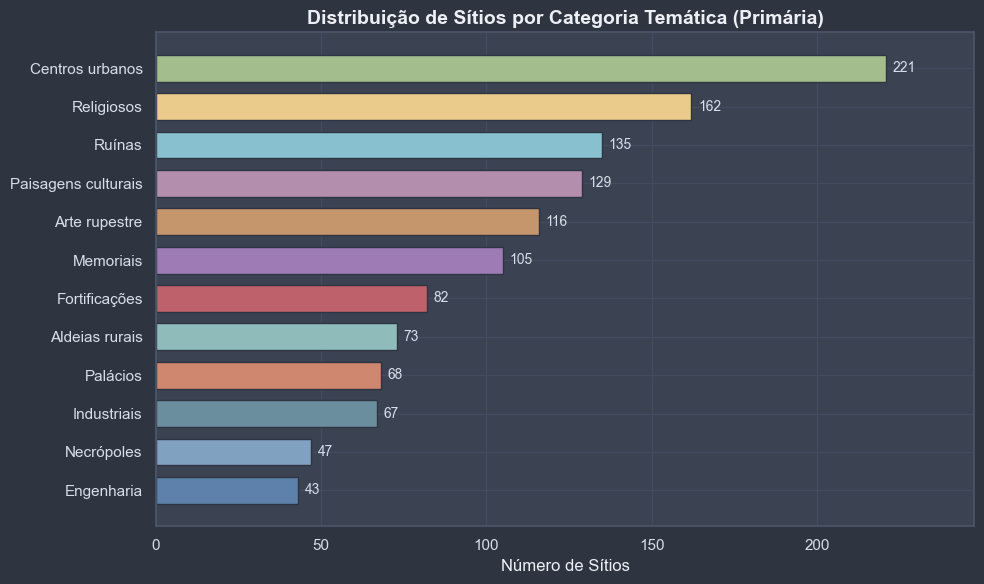

In [31]:
counts = nlp_df["category_thematic"].value_counts().sort_values()
short_counts = counts.rename(index=SHORT_CAT)
colors_bar = [CAT_COLOR_MAP[cat] for cat in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    short_counts.index,
    short_counts.values,
    color=colors_bar,
    edgecolor="#2E3440",
    height=0.7,
)
for bar, val in zip(bars, short_counts.values):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        str(int(val)),
        va="center", color="#D8DEE9", fontsize=10,
    )
ax.set_xlim(0, short_counts.max() * 1.12)
ax.set_title("Distribuição de Sítios por Categoria Temática (Primária)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Número de Sítios")
plt.tight_layout()
plt.show()

## 4.4 Distribuição Geográfica das Categorias Temáticas

Cada sítio plotado na sua localização geográfica, colorido pela categoria temática
primária. Permite identificar padrões regionais: *Ruínas* no Mediterrâneo e Oriente
Médio, *Religiosos* na Ásia, *Industriais* concentrados na Europa Ocidental,
*Arte rupestre* na Europa e América do Sul.

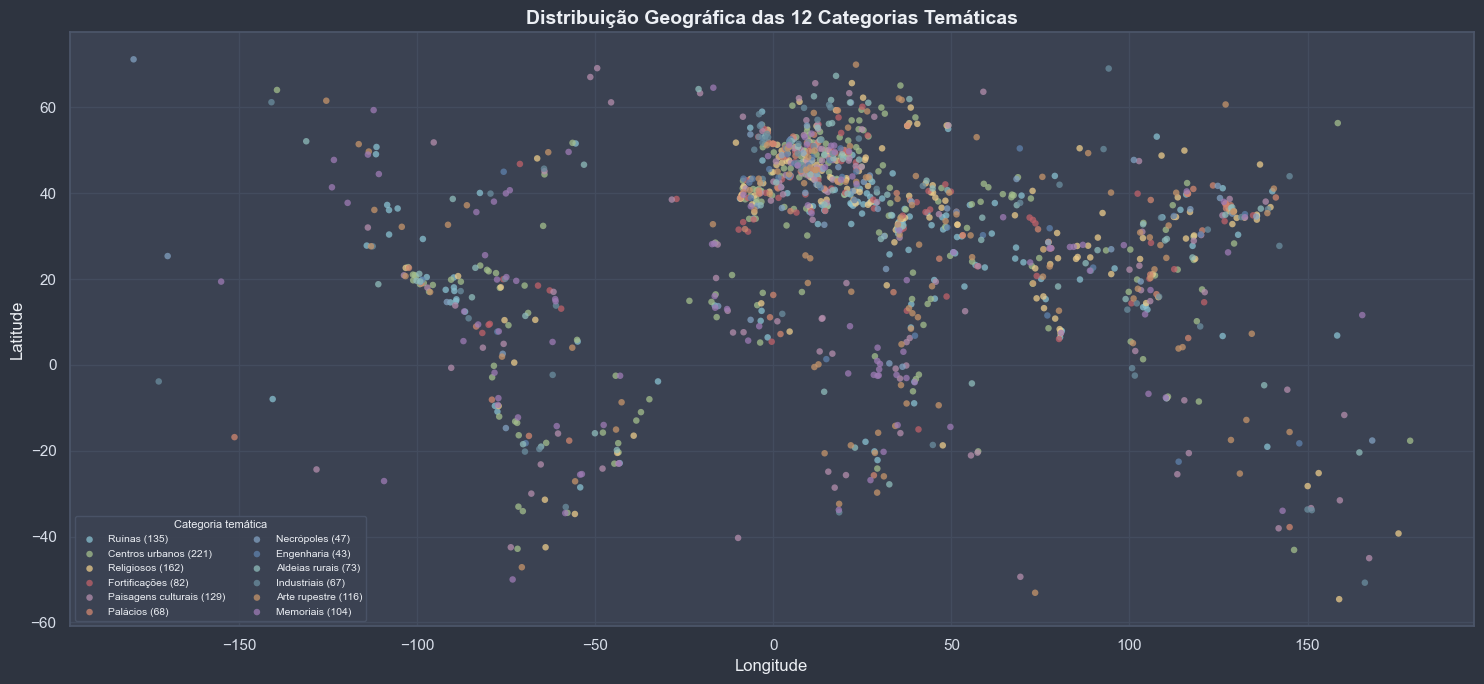

In [32]:
geo_thematic = nlp_df.dropna(subset=["latitude", "longitude"])

fig, ax = plt.subplots(figsize=(15, 7))
for cat in CATEGORIES:
    mask = geo_thematic["category_thematic"] == cat
    if not mask.any():
        continue
    ax.scatter(
        geo_thematic.loc[mask, "longitude"],
        geo_thematic.loc[mask, "latitude"],
        c=CAT_COLOR_MAP[cat],
        label=f"{SHORT_CAT[cat]} ({int(mask.sum())})",
        s=22, alpha=0.75, edgecolors="none",
    )
ax.legend(loc="lower left", fontsize=7.5, ncol=2, framealpha=0.85,
          title="Categoria temática", title_fontsize=8)
ax.set_title("Distribuição Geográfica das 12 Categorias Temáticas", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 4.5 Co-ocorrência de Categorias (Multi-label)

Cada sítio pode pertencer a mais de uma categoria temática quando sua similaridade
supera o limiar. O heatmap conta quantos sítios receberam simultaneamente cada par
de categorias — pares com alta co-ocorrência revelam categorias semanticamente
próximas no vocabulário TF-IDF.

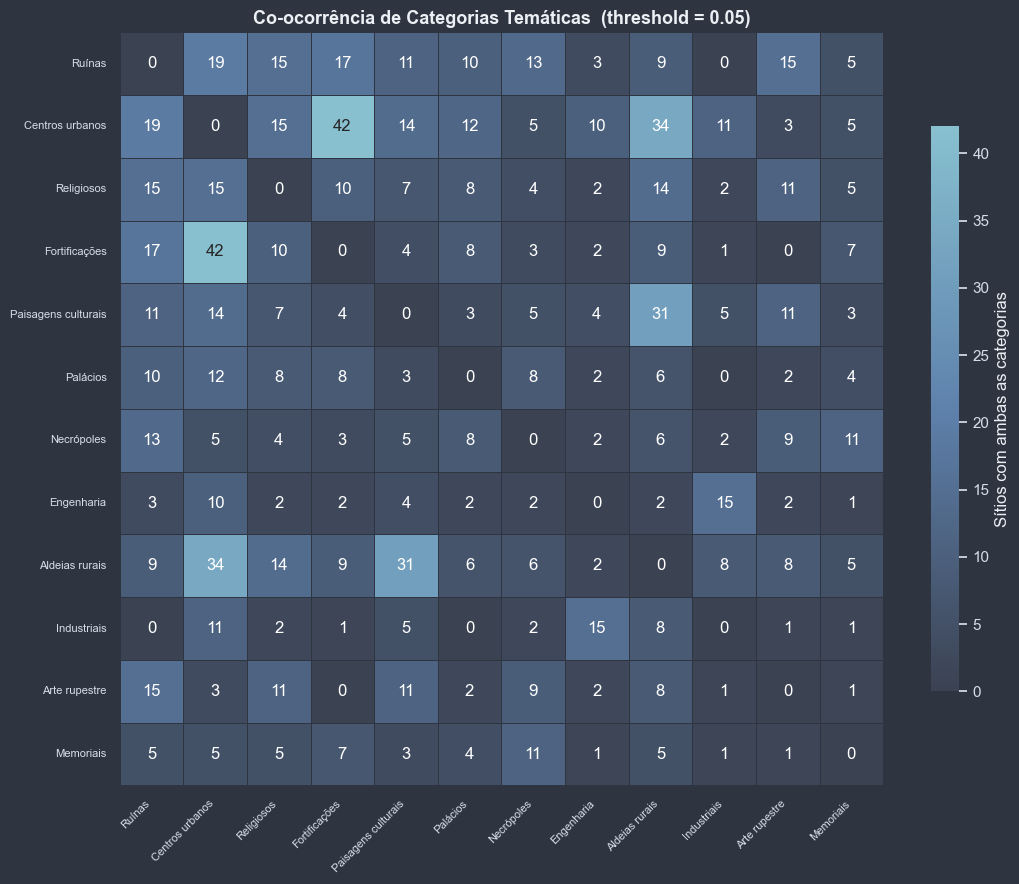

In [33]:
cooc = pd.DataFrame(0, index=CATEGORIES, columns=CATEGORIES)
for cats in nlp_df["categories_multi"]:
    for a in cats:
        for b in cats:
            if a != b:
                cooc.loc[a, b] += 1

cooc.index = [SHORT_CAT.get(c, c) for c in cooc.index]
cooc.columns = [SHORT_CAT.get(c, c) for c in cooc.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cooc,
    annot=True,
    fmt="d",
    cmap=LinearSegmentedColormap.from_list("nord_seq", ["#3B4252", "#5E81AC", "#88C0D0"]),
    linewidths=0.5,
    linecolor="#2E3440",
    ax=ax,
    cbar_kws={"shrink": 0.75, "label": "Sítios com ambas as categorias"},
)
ax.set_title(
    f"Co-ocorrência de Categorias Temáticas  (threshold = {MULTILABEL_THRESHOLD})",
    fontsize=13, fontweight="bold",
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## 4.6 Categorias Temáticas × Classificação UNESCO

Composição de cada categoria temática segundo a classificação oficial da UNESCO
(Cultural, Natural, Mixed). Permite verificar se o modelo captura o sinal esperado:
*Ruínas*, *Religiosos* e *Palácios* devem ser majoritariamente Culturais;
*Paisagens culturais* deve ser a categoria que mais absorve sítios Natural e Mixed.

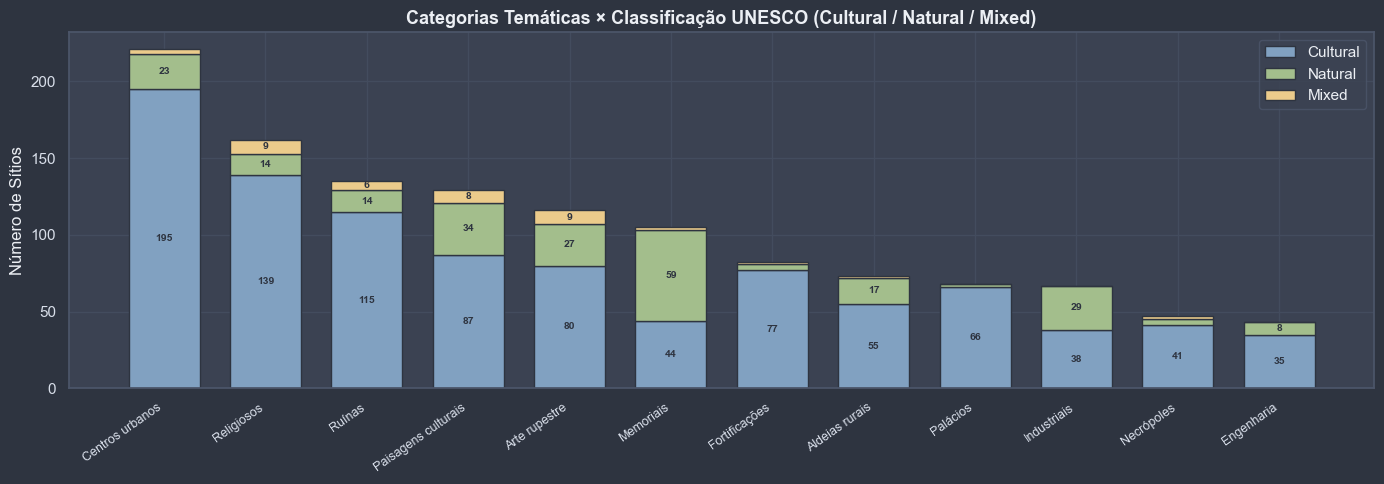

In [34]:
cross = (
    nlp_df.dropna(subset=["category"])
    .groupby(["category_thematic", "category"])
    .size()
    .unstack(fill_value=0)
)
cross.index = cross.index.map(SHORT_CAT)
cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).index]

unesco_colors: dict[str, str] = {"Cultural": "#81A1C1", "Natural": "#A3BE8C", "Mixed": "#EBCB8B"}
cats_available = [c for c in ["Cultural", "Natural", "Mixed"] if c in cross.columns]
x = np.arange(len(cross))

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(cross))
for uc in cats_available:
    vals = cross[uc].values
    ax.bar(x, vals, bottom=bottom, label=uc, color=unesco_colors[uc], edgecolor="#2E3440", width=0.7)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 5:
            ax.text(i, b + v / 2, str(int(v)), ha="center", va="center",
                    color="#2E3440", fontsize=7.5, fontweight="bold")
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(cross.index, rotation=35, ha="right", fontsize=9)
ax.set_title(
    "Categorias Temáticas × Classificação UNESCO (Cultural / Natural / Mixed)",
    fontsize=13, fontweight="bold",
)
ax.set_ylabel("Número de Sítios")
ax.legend()
plt.tight_layout()
plt.show()